# Reflection Agent

A **Reflection Agent** is an AI agent that does not stop after giving its first answer.
It pauses, checks its own work, finds mistakes, and then improves the answer.

Think of it like this:
1. First attempt: "Let me solve this."
2. Reflection: "Did I miss anything?"
3. Improved attempt: "Here is a better and more accurate answer."

## Why Reflection Agents are useful
- They reduce simple mistakes.
- They improve answer quality step by step.
- They are better for complex tasks like coding, planning, and reasoning.

## Basic flow of a Reflection Agent
1. **Generate**: Produce an initial answer.
2. **Review**: Criticize or evaluate that answer.
3. **Revise**: Create a better version using the feedback.
4. **Repeat (optional)**: Continue until quality is good enough.

## Simple real-world example
- Task: "Write an email to a customer."
- First draft: Agent writes a basic email.
- Reflection: Agent checks tone, clarity, grammar, and missing details.
- Final draft: Agent sends a clearer and more professional email.

## Reflection Agent vs Normal Agent
- **Normal agent**: usually gives one answer and stops.
- **Reflection agent**: gives an answer, checks it, and improves it.

## Important point
Reflection does not guarantee perfect answers, but it usually gives **more reliable** results than a single-shot response.

In [1]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [2]:
# Core LLM + tool + graph imports
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, HumanMessage
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# In-memory checkpoint store for multi-turn thread conversations
from langgraph.checkpoint.memory import MemorySaver


# Standard library typing/date utilities
from datetime import datetime
from typing import List, Optional, Annotated, Union, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import ast
import operator
import re


In [3]:
# Initialize the base chat model and attach tracing callbacks
generation_llm = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    # model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

# Initialize a separate LLM instance for reflaction with the same tracing callbacks
reflaction_llm = ChatNVIDIA(
    #model="openai/gpt-oss-120b",
    model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [4]:
# Prompt for the report generation

generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional report generator that creates detailed reports based on user-provided topics and information."
            "Generate the detailed report based on the user's topic",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generate_report = generation_prompt | generation_llm

In [5]:
# Prompt for reflection
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant for reflecting on the generated report."
            "Analyze the provided report and identify any potential issues, inaccuracies, or areas for improvement."
            "Provide constructive feedback and suggestions to enhance the quality"
        )
    ]
)

In [6]:
# Create the reflection chain by piping the prompt with the LLM
reflect_on_report = reflection_prompt | reflaction_llm

# Prompt for reviewing/polishing the writing
review_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert editor for professional reports. "
            "Review the provided text and suggest improvements for clarity, coherence, and impact."
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# Create the review chain
review_writing = review_prompt | reflaction_llm

In [7]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    Article: Optional[str]


In [8]:
builder  = StateGraph(State)

In [9]:
# Define the node function that generates the report and updates the state with the generated report for reflection

# If you are using async LLMs, make sure to define the node function as async and use await when invoking the LLM.
# Use ainvoke for async calls to the LLM and invoke for sync calls.

async def generate_report_and_reflect(state: State) -> dict:
    # Feed only message history into the prompt chain
    result = await generate_report.ainvoke({"messages": state["messages"]})
    return {"messages": [result]}

builder.add_node(
    "generate",
    generate_report_and_reflect,
)

In [10]:
async def reflect_on_report_node(state: State) -> dict:
    # Reflect using the accumulated message objects directly
    reflection_result = await reflect_on_report.ainvoke({"messages": state["messages"]})

    # Feed reflection back as human input for the next generation step
    return {"messages": [HumanMessage(content=reflection_result.content)]}


async def review_writing_node(state: State) -> dict:
    # Review the best full AI draft instead of the entire mixed conversation.
    ai_drafts = [
        msg.content
        for msg in state["messages"]
        if getattr(msg, "type", "").lower() == "ai" and getattr(msg, "content", "")
    ]
    if not ai_drafts:
        return {"messages": []}

    base_draft = max(ai_drafts, key=len)
    review_input = [HumanMessage(content=base_draft)]
    reviewed = await review_writing.ainvoke({"messages": review_input})
    return {"messages": [reviewed]}


async def finalize_article_node(state: State) -> dict:
    # Persist final report text into Article after the cycle completes
    final_ai = next(
        (
            msg.content
            for msg in reversed(state["messages"])
            if getattr(msg, "type", "").lower() == "ai"
        ),
        "",
    )
    return {"Article": final_ai}


builder.add_node("reflect", reflect_on_report_node)
builder.add_node("review_writing", review_writing_node)
builder.add_node("finalize_article", finalize_article_node)

In [11]:
def should_continue(state: State) -> str:
    if len(state["messages"]) > 10:
        return "review_writing"
    return "reflect"

In [12]:
builder.add_conditional_edges(
    "generate",
    should_continue,
    {
        "reflect": "reflect",
        "review_writing": "review_writing",
    },
)

In [13]:
builder.add_edge(START, "generate")
builder.add_edge("reflect", "generate")
builder.add_edge("review_writing", "finalize_article")
builder.add_edge("finalize_article", END)

In [14]:
# show the graph structure
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

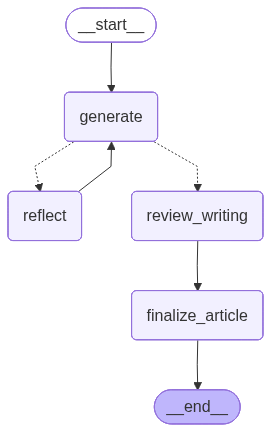

In [15]:
graph

In [16]:
config = {"configurable":{"thread_id": "1"}}
topic = "The impact of climate change on global agriculture"

In [17]:
async def preview_generate_and_reflect(state: State) -> Tuple[str, str]:
    # Generate the report based on the current state messages
    result = await generate_report.ainvoke({"messages": state["messages"]})

    reflection_result = await reflect_on_report.ainvoke({"messages": state["messages"]})

    # Return plain text for quick comparison outside graph execution
    return result.content, reflection_result.content

In [18]:
import json
from pathlib import Path

result = await graph.ainvoke(
    {"messages": [HumanMessage(content=topic)]},
    config=config,
)

messages = result.get("messages", [])
serializable_messages = [
    {
        "index": i,
        "role": getattr(msg, "type", msg.__class__.__name__),
        "content": getattr(msg, "content", str(msg)),
    }
    for i, msg in enumerate(messages, start=1)
]

output_path = Path("Plan and Execute") / "reflection_output_full.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(
    json.dumps(serializable_messages, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(f"Saved full output to: {output_path.resolve()}")
print(f"Total messages: {len(serializable_messages)}")
print("\nPreview (first 3 messages):\n")
for item in serializable_messages[:3]:
    print(f"[{item['index']}] {item['role'].upper()}")
    print("-" * 60)
    print(item["content"][:1000])
    print()

serializable_messages

Saved full output to: /mnt/A682FEDC82FEAFC3/Projects/LLM/Agents/Plan and Execute/Plan and Execute/reflection_output_full.json
Total messages: 13

Preview (first 3 messages):

[1] HUMAN
------------------------------------------------------------
The impact of climate change on global agriculture

[2] AI
------------------------------------------------------------
**Report Title:**  
**The Impact of Climate Change on Global Agriculture – Risks, Opportunities, and Pathways for Resilience**  

**Prepared for:** [Client/Organization]  
**Prepared by:** Professional Report Generation Service  
**Date:** 21 April 2026  

---

## Table of Contents
1. Executive Summary ……………………………………………………………………… 3  
2. Introduction ……………………………………………………………………………… 4  
3. Climate‑Change Drivers Relevant to Agriculture ……………………………………… 5  
4. Physical Impacts on Agricultural Systems ………………………………………… 7  
   - 4.1 Temperature & Phenology  
   - 4.2 Precipitation & Water Availability  
   - 4.3 Extreme Weather Events

[{'index': 1,
  'role': 'human',
  'content': 'The impact of climate change on global agriculture'},
 {'index': 2,
  'role': 'ai',
  'content': '**Report Title:**  \n**The Impact of Climate Change on Global Agriculture – Risks, Opportunities, and Pathways for Resilience**  \n\n**Prepared for:**\u202f[Client/Organization]  \n**Prepared by:**\u202fProfessional Report Generation Service  \n**Date:**\u202f21\u202fApril\u202f2026  \n\n---\n\n## Table of Contents\n1. Executive Summary ……………………………………………………………………… 3  \n2. Introduction ……………………………………………………………………………… 4  \n3. Climate‑Change Drivers Relevant to Agriculture ……………………………………… 5  \n4. Physical Impacts on Agricultural Systems ………………………………………… 7  \n   - 4.1 Temperature & Phenology  \n   - 4.2 Precipitation & Water Availability  \n   - 4.3 Extreme Weather Events  \n   - 4.4 Atmospheric CO₂ Fertilisation  \n   - 4.5 Soil Health & Nutrient Cycling  \n5. Biological Impacts ……………………………………………………………………… 12  \n   - 5.1 Pests, Pathogens & Invasiv

In [19]:
from pathlib import Path
import json
from IPython.display import Markdown, display

# Read exported conversation JSON
candidates = [
    Path("Plan and Execute") / "reflection_output_full.json",
    Path("Plan and Execute") / "Plan and Execute" / "reflection_output_full.json",
    Path("reflection_output_full.json"),
]

json_path = next((p for p in candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("reflection_output_full.json not found in expected locations")

data = json.loads(json_path.read_text(encoding="utf-8"))

display(Markdown(f"## Conversation Transcript ({len(data)} turns)"))
for item in data:
    step = item.get("index", "?")
    role = str(item.get("role", "unknown")).upper()
    content = item.get("content", "")
    block = (
        f"### Step {step} | {role}\n"
        f"---\n\n"
        f"{content}"
    )
    display(Markdown(block))

## Conversation Transcript (13 turns)

### Step 1 | HUMAN
---

The impact of climate change on global agriculture

### Step 2 | AI
---

**Report Title:**  
**The Impact of Climate Change on Global Agriculture – Risks, Opportunities, and Pathways for Resilience**  

**Prepared for:** [Client/Organization]  
**Prepared by:** Professional Report Generation Service  
**Date:** 21 April 2026  

---

## Table of Contents
1. Executive Summary ……………………………………………………………………… 3  
2. Introduction ……………………………………………………………………………… 4  
3. Climate‑Change Drivers Relevant to Agriculture ……………………………………… 5  
4. Physical Impacts on Agricultural Systems ………………………………………… 7  
   - 4.1 Temperature & Phenology  
   - 4.2 Precipitation & Water Availability  
   - 4.3 Extreme Weather Events  
   - 4.4 Atmospheric CO₂ Fertilisation  
   - 4.5 Soil Health & Nutrient Cycling  
5. Biological Impacts ……………………………………………………………………… 12  
   - 5.1 Pests, Pathogens & Invasive Species  
   - 5.2 Pollinators & Beneficial Organisms  
6. Regional & Crop‑Specific Vulnerability Assessment …………………………………… 15  
   - 6.1 Sub‑Saharan Africa  
   - 6.2 South Asia & the Indo‑Gangetic Plain  
   - 6.3 East Asia & the Pacific  
   - 6.4 Latin America & the Caribbean  
   - 6.5 North America & Europe  
   - 6.6 High‑Altitude & Arctic Zones  
7. Socio‑Economic Consequences ………………………………………………………… 22  
8. Adaptation Strategies & Technological Innovations …………………………… 25  
   - 8.1 Crop Breeding & Biotechnology  
   - 8.2 Climate‑Smart Agronomy  
   - 8.3 Water‑Management & Irrigation Efficiency  
   - 8.4 Soil Carbon Sequestration & Conservation Agriculture  
   - 8.5 Digital Agriculture & Early‑Warning Systems  
9. Mitigation Opportunities Within Agriculture ……………………………………… 31  
10. Policy Landscape & Recommendations ………………………………………………… 34  
11. Future Outlook & Scenario Analysis (2025‑2100) …………………………………… 38  
12. Conclusions ……………………………………………………………………………… 42  
13. References & Further Reading ………………………………………………………… 44  

---

## 1. Executive Summary  

Climate change is reshaping the physical environment in which crops, livestock, and fisheries are produced. The Intergovernmental Panel on Climate Change (IPCC) Sixth Assessment Report (2023) projects a **global mean surface temperature rise of 1.5 °C by 2035** under current policies, with regional warming up to 3 °C in low‑latitude zones. This warming, combined with altered precipitation patterns, more frequent extreme events, and rising atmospheric CO₂, is already manifesting as:

| Impact Category | Key Observations (2020‑2025) | Projected Trend (2030‑2100) |
|-----------------|-----------------------------|-----------------------------|
| **Yield Gaps** | Global cereal yield growth slowed to 0.5 % yr⁻¹ (vs. 1.2 % yr⁻¹ in 1990‑2000) | Net yield decline of 10‑25 % for wheat, maize, and rice in the tropics; modest gains (+2‑5 %) in high‑latitude temperate zones |
| **Heat Stress** | > 30 % of global wheat area experienced ≥ 35 °C during grain fill in 2022 | Heat‑stress days projected to double in South Asia and Sub‑Saharan Africa by 2050 |
| **Water Scarcity** | 45 % of major irrigated basins reported reduced reliability (e.g., Indus, Yellow River) | 60‑80 % of irrigated agriculture at risk of water deficit under RCP8.5 |
| **Pest & Disease Pressure** | Outbreaks of fall armyworm, wheat rust, and coffee leaf rust increased 40 % since 2015 | Geographic range expansion of > 30 % for major pests; up to 3‑fold increase in disease incidence |
| **CO₂ Fertilisation** | Yield gains of 5‑10 %

### Step 3 | HUMAN
---

However, I don't see a report provided. Please share the report you'd like me to analyze, and I'll do my best to:

1. Identify potential issues or inaccuracies
2. Highlight areas for improvement
3. Provide constructive feedback and suggestions to enhance the quality

Please paste the report, and I'll get started.

### Step 4 | AI
---

Sure thing! I’m ready to dive in and give you a thorough, constructive review.  

When you’re ready, just paste the full text (or the sections you’d like me to focus on) and I’ll:

1. **Spot any factual, logical, or methodological issues** – e.g., data inconsistencies, unsupported claims, or gaps in the argument.  
2. **Identify areas where the structure, flow, or clarity could be improved** – headings, transitions, visual aids, etc.  
3. **Provide concrete suggestions** for strengthening the analysis, tightening the language, and enhancing overall readability and impact.

Feel free to let me know if there are particular aspects you’re most concerned about (e.g., data accuracy, citation style, executive‑summary effectiveness, etc.). I’ll tailor the feedback accordingly.  

Whenever you’re ready, just drop the report in the chat and we’ll get started!

...

### Step 9 | HUMAN
---

However, I don't see a report provided. Please share the report you'd like me to analyze, and I'll do my best to:

1. Identify potential issues or inaccuracies
2. Highlight areas for improvement
3. Provide constructive feedback and suggestions to enhance the quality

Please paste the report, and I'll get started.

### Step 10 | AI
---

I’m ready to dive in as soon as you share the document you’d like reviewed.  

If you have the report handy, just paste the full text (or the sections you want me to focus on) into the chat.  

If you don’t have a report yet and would like a **sample** that you can then edit or use as a starting point, let me know— I can generate a draft on a topic of your choice (e.g., climate‑change impacts on agriculture, market analysis, project evaluation, etc.) and then we can review it together.

Just let me know which option works best for you, and we’ll get started!

### Step 11 | HUMAN
---

However, I don't see a report provided. Please share the report you'd like me to analyze, and I'll do my best to:

1. Identify potential issues or inaccuracies
2. Highlight areas for improvement
3. Provide constructive feedback and suggestions to enhance the quality

Please paste the report, and I'll get started.

### Step 12 | AI
---

I’m ready to help you improve the document, but I’ll need the text you’d like reviewed.  

**Please paste the report (or the specific sections you want feedback on) into the chat**, and let me know if there are any particular aspects you’re most concerned about—e.g.:

* Data accuracy or source citation  
* Logical flow and structure  
* Clarity of the executive summary or conclusions  
* Formatting, tables, or visual aids  
* Tone, style, or audience suitability  

If you don’t have a report on hand and would like a **sample draft** to work from (for example, a report on the impact of climate change on global agriculture, a market‑analysis brief, a project‑evaluation summary, etc.), just let me know the topic and the level of detail you need, and I can generate one for you to review.

Once I have the document (or a sample you’d like to refine), I’ll:

1. Spot any factual, logical, or methodological issues.  
2. Highlight areas where the organization, flow, or clarity can be improved.  
3. Provide concrete, actionable suggestions to strengthen the analysis and polish the language.

Looking forward to receiving the report!

### Step 13 | AI
---

**Report Review and Suggestions for Improvement**

**Overall Assessment:**
The report provides a comprehensive overview of the impact of climate change on global agriculture, covering various aspects such as physical and biological impacts, regional vulnerability assessments, socio-economic consequences, adaptation strategies, and mitigation opportunities. The report is well-structured, and the use of tables and headings enhances readability.

**Suggestions for Improvement:**

1. **Executive Summary:**
	* Consider adding a brief overview of the report's objectives, methodology, and key findings.
	* Use a more concise and clear format for the table, avoiding excessive use of abbreviations and technical terms.
	* Provide a clear call-to-action or recommendation for stakeholders.
2. **Introduction:**
	* Clearly define the scope and objectives of the report.
	* Provide a brief overview of the current state of global agriculture and the importance of addressing climate change.
	* Consider adding a section on the report's methodology and data sources.
3. **Climate-Change Drivers Relevant to Agriculture:**
	* Use clear and concise headings and subheadings to break up the content.
	* Consider adding visual aids such as diagrams or infographics to illustrate the relationships between climate change drivers and agricultural impacts.
4. **Physical Impacts on Agricultural Systems:**
	* Use clear and concise language to explain technical terms and concepts.
	* Consider adding case studies or examples to illustrate the impacts of climate change on different agricultural systems.
5. **Regional & Crop-Specific Vulnerability Assessment:**
	* Use clear and concise headings and subheadings to break up the content.
	* Consider adding maps or visual aids to illustrate regional vulnerability and crop-specific impacts.
6. **Socio-Economic Consequences:**
	* Use clear and concise language to explain technical terms and concepts.
	* Consider adding case studies or examples to illustrate the socio-economic impacts of climate change on different agricultural communities.
7. **Adaptation Strategies & Technological Innovations:**
	* Use clear and concise headings and subheadings to break up the content.
	* Consider adding examples or case studies to illustrate the effectiveness of different adaptation strategies and technological innovations.
8. **Mitigation Opportunities Within Agriculture:**
	* Use clear and concise language to explain technical terms and concepts.
	* Consider adding examples or case studies to illustrate the potential of different mitigation opportunities.
9. **Policy Landscape & Recommendations:**
	* Use clear and concise language to explain technical terms and concepts.
	* Consider adding a clear call-to-action or recommendation for policymakers and stakeholders.
10. **Future Outlook & Scenario Analysis (2025-2100):**
	* Use clear and concise language to explain technical terms and concepts.
	* Consider adding visual aids such as diagrams or infographics to illustrate the potential future scenarios.

**Additional Suggestions:**

1. **Use clear and concise language** throughout the report, avoiding excessive use of technical terms and jargon.
2. **Use visual aids** such as diagrams, infographics, and maps to illustrate complex concepts and data.
3. **Add case studies or examples** to illustrate the impacts of climate change on different agricultural systems and communities.
4. **Use clear and concise headings and subheadings** to break up the content and enhance readability.
5. **Provide a clear call-to-action or recommendation** for stakeholders and policymakers.
6. **Consider adding an appendix** with additional data, references, or technical information.

By implementing these suggestions, the report can be improved in terms of clarity, coherence, and impact, making it more effective in communicating the critical issues and opportunities related to climate change and global agriculture.

In [20]:
from pathlib import Path
from uuid import uuid4
import re


def _slugify(title: str) -> str:
    slug = title.strip().lower()
    slug = re.sub(r"[`*_]", "", slug)
    slug = re.sub(r"[^a-z0-9\s-]", "", slug)
    slug = re.sub(r"\s+", "-", slug)
    slug = re.sub(r"-+", "-", slug)
    return slug.strip("-")


def _extract_headings(markdown_text: str):
    headings = []
    for line in markdown_text.splitlines():
        match = re.match(r"^(#{2,3})\s+(.+?)\s*$", line)
        if not match:
            continue
        level = len(match.group(1))
        title = match.group(2).strip()
        title = re.sub(r"\s*\{#.*\}\s*$", "", title)
        headings.append((level, title))
    return headings


def _pick_best_full_report(messages) -> str:
    """Pick the most complete AI report message from graph output."""
    ai_contents = [
        getattr(msg, "content", "")
        for msg in messages
        if getattr(msg, "type", "").lower() == "ai"
    ]
    ai_contents = [c for c in ai_contents if c and isinstance(c, str)]
    if not ai_contents:
        raise ValueError("No AI report content found in graph output.")

    def score(content: str) -> float:
        lower = content.lower()
        heading_count = len(_extract_headings(content))
        has_toc_marker = "table of contents" in lower
        has_title = content.lstrip().startswith("#")
        return (
            heading_count * 3
            + (3 if has_toc_marker else 0)
            + (2 if has_title else 0)
            + min(len(content) / 3000, 8)
        )

    return max(ai_contents, key=score)


def _build_toc(markdown_text: str) -> str:
    headings = _extract_headings(markdown_text)
    headings = [(lvl, t) for (lvl, t) in headings if t.strip().lower() != "table of contents"]

    if not headings:
        return "## Table of Contents\n\n- No headings found\n"

    toc_lines = ["## Table of Contents", ""]
    for level, title in headings:
        indent = "  " if level == 3 else ""
        anchor = _slugify(title)
        toc_lines.append(f"{indent}- [{title}](#{anchor})")
    toc_lines.append("")
    return "\n".join(toc_lines)


def _remove_existing_toc(markdown_text: str) -> str:
    lines = markdown_text.splitlines()
    start_idx = None
    for i, line in enumerate(lines):
        if re.match(r"^##\s+table\s+of\s+contents\s*$", line.strip(), flags=re.IGNORECASE):
            start_idx = i
            break

    if start_idx is None:
        return markdown_text

    end_idx = len(lines)
    for j in range(start_idx + 1, len(lines)):
        if re.match(r"^##\s+", lines[j]):
            end_idx = j
            break

    cleaned = lines[:start_idx] + lines[end_idx:]
    return "\n".join(cleaned).strip() + "\n"


def _insert_fresh_toc(markdown_text: str) -> str:
    cleaned = _remove_existing_toc(markdown_text)
    toc = _build_toc(cleaned)
    lines = cleaned.splitlines()

    first_h2 = None
    for i, line in enumerate(lines):
        if re.match(r"^##\s+", line):
            first_h2 = i
            break

    if first_h2 is None:
        return cleaned.rstrip() + "\n\n" + toc

    head = "\n".join(lines[:first_h2]).rstrip()
    tail = "\n".join(lines[first_h2:]).lstrip()
    return f"{head}\n\n{toc}\n{tail}\n"


def _report_instruction(topic: str) -> str:
    """Topic-agnostic instruction so this works for any subject."""
    lines = [
        f"Write a complete, professional markdown report on: {topic}",
        "",
        "Requirements:",
        "- Start with one H1 title.",
        "- Include a concise executive summary.",
        "- Use multiple H2/H3 sections with clear structure.",
        "- Add evidence-based details, examples, and practical recommendations.",
        "- Keep content coherent from start to end (not fragmented).",
        "- Output valid markdown only.",
    ]
    return "\n".join(lines)


async def generate_full_report_markdown(
    topic: str,
    graph,
    output_file: str | None = None,
    thread_id: str | None = None,
) -> Path:
    """Generate a full markdown report for any topic and auto-sync its TOC."""
    safe_name = re.sub(r"[^a-zA-Z0-9]+", "_", topic.strip()).strip("_").lower() or "report"
    output_file = output_file or f"{safe_name}_report.md"

    thread_id = thread_id or f"report-{uuid4().hex[:8]}"
    config = {"configurable": {"thread_id": thread_id}}

    request = _report_instruction(topic)
    result = await graph.ainvoke(
        {"messages": [HumanMessage(content=request)]},
        config=config,
    )

    final_ai_content = _pick_best_full_report(result.get("messages", []))
    final_with_toc = _insert_fresh_toc(final_ai_content)

    output_path = Path(output_file)
    output_path.write_text(final_with_toc, encoding="utf-8")

    print(f"Report saved to: {output_path.resolve()}")
    print(f"Thread used: {thread_id}")
    return output_path


# saved_md = await generate_full_report_markdown("AI in healthcare", graph)
# saved_md = await generate_full_report_markdown("Future of renewable energy", graph, output_file="energy_report.md")

In [ ]:
saved_md = await generate_full_report_markdown(
    "Global water scarcity and policy options",
    graph,
    output_file="water_scarcity_report.md"
)

In [ ]:
# Generic run helper: get final state and inspect Article
import asyncio
from uuid import uuid4

run_topic = "Future of Renewable Energy"
run_config = {
    "configurable": {
        # Use a fresh thread id to avoid stale checkpoint state
        "thread_id": f"generic-article-check-{uuid4().hex[:8]}"
    }
}

MAX_RETRIES = 3
TIMEOUT_SECONDS = 240
run_result = None

for attempt in range(1, MAX_RETRIES + 1):
    try:
        run_result = await asyncio.wait_for(
            graph.ainvoke(
                {"messages": [HumanMessage(content=run_topic)]},
                config=run_config,
            ),
            timeout=TIMEOUT_SECONDS,
        )
        break
    except (asyncio.CancelledError, asyncio.TimeoutError) as exc:
        print(f"Attempt {attempt}/{MAX_RETRIES} failed: {type(exc).__name__}")
        if attempt == MAX_RETRIES:
            raise
        await asyncio.sleep(2 * attempt)

print("Article key present:", "Article" in run_result)
print("Article length:", len(run_result.get("Article", "")))
print("Article preview:\n")
print(run_result.get("Article", "")[:1200])

CancelledError: 